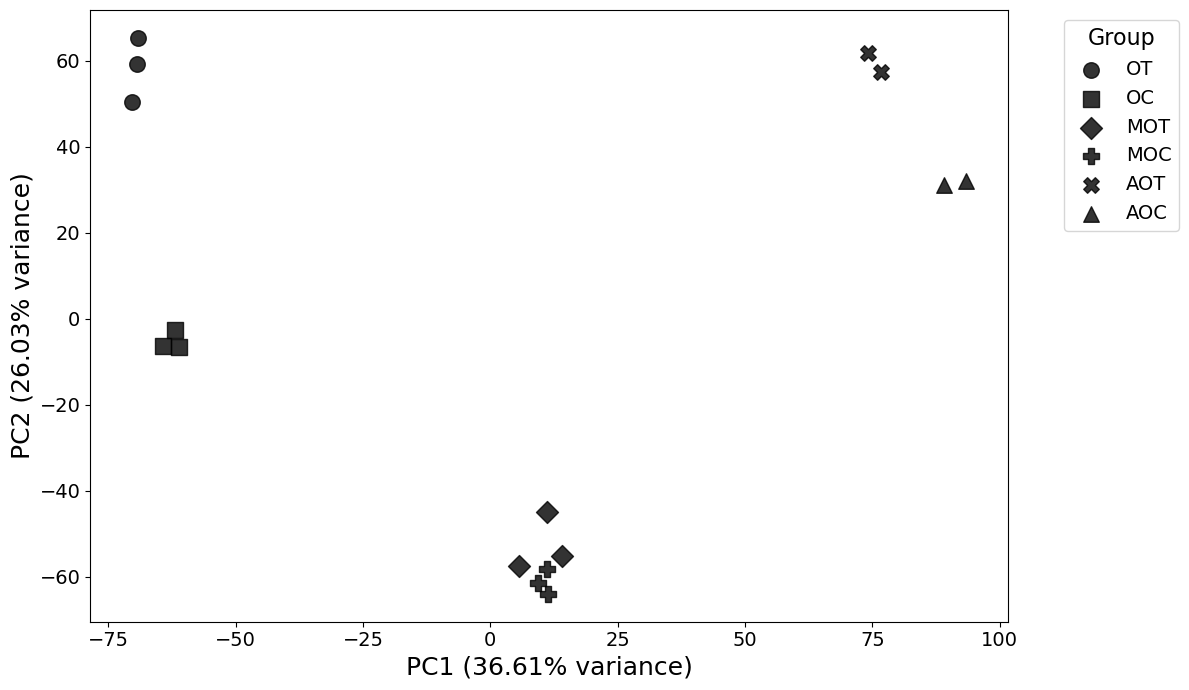

In [9]:
# Import required libraries
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Function to perform PCA and generate a plot
def plot_pca_for_groups(data, groups, selected_groups, title="PCA Plot"):
    # Filter data and groups
    selected_columns = [col for col, grp in zip(data.columns, groups) if grp in selected_groups]
    filtered_data = data[selected_columns]
    filtered_groups = [grp for grp in groups if grp in selected_groups]
    
    # Transpose and scale the filtered data
    filtered_data_transposed = filtered_data.T
    scaler = StandardScaler()
    filtered_data_scaled = scaler.fit_transform(filtered_data_transposed)

    # Perform PCA
    filtered_pca = PCA(n_components=2)
    filtered_pca_result = filtered_pca.fit_transform(filtered_data_scaled)
    filtered_explained_variance = filtered_pca.explained_variance_ratio_ * 100

    # Create a DataFrame for PCA results
    filtered_pca_df = pd.DataFrame(filtered_pca_result, columns=["PC1", "PC2"])
    filtered_pca_df["Group"] = filtered_groups

    # Set markers for groups
    markers = ["o", "s", "D", "P", "X", "^"]  # Customize as needed
    group_to_marker = {group: markers[i % len(markers)] for i, group in enumerate(selected_groups)}

    # Plot PCA
    plt.figure(figsize=(12, 7))
    for group in selected_groups:
        subset = filtered_pca_df[filtered_pca_df["Group"] == group]
        plt.scatter(
            subset["PC1"], subset["PC2"],
            label=group,
            marker=group_to_marker[group],
            s=125,
            c="black",  # Set marker color to black
            alpha=0.8
        )

    plt.xlabel(f"PC1 ({filtered_explained_variance[0]:.2f}% variance)", fontsize=18)
    plt.ylabel(f"PC2 ({filtered_explained_variance[1]:.2f}% variance)", fontsize=18)
    # plt.title(title, fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc="upper left", title_fontsize=16, fontsize=14)
    plt.grid(False)  # Disable grid
    plt.tight_layout()
    plt.savefig("/home/nanopore/projects/rna_seq_workflow/results/20250603_FCOM/DEG_analysis/plots/PCA_plot_all_groups.png", dpi=300)

# Load the data
data = pd.read_csv("/home/nanopore/projects/rna_seq_workflow/results/20250603_FCOM/DEG_analysis/20250603_FCOM_normalized_counts.csv", index_col=0)
data.rename(columns={"OK1": "OC1", "OK2": "OC2", "OK3": "OC3", "MOK1": "MOC1", "MOK2": "MOC2", "MOK3": "MOC3", "AOK1": "AOC1", "AOK2": "AOC2", "AOK3": "AOC3"}, inplace=True)  # Rename columns
# Extract group labels from column names
samples = data.columns
groups = samples.str.extract(r"([a-zA-Z]+)")[0].values  # Extract text portion of sample names
# Example 1: Plot PCA for all groups
pca_plot = plot_pca_for_groups(data, groups, ["OT", "OC", "MOT", "MOC","AOT","AOC"],
                    title="PCA Plot: All Groups")

pca_plot